# Graph Adjacency Representations

Consider the following directed graph with 4 nodes and 5 edges:

$$A = \begin{bmatrix} 0 & 1 & 0 & 1 \\ 0 & 0 & 1 & 0 \\ 1 & 0 & 0 & 1 \\ 0 & 0 & 0 & 0 \end{bmatrix}$$

The non-zero entries are at positions $(0,1), (0,3), (1,2), (2,0), (2,3)$ — 5 edges among $N=4$ nodes.

---

## 1. Dense matrix

Store every entry, including zeros. For $N$ nodes, this requires $N^2$ values regardless of how many edges exist.

| | 0 | 1 | 2 | 3 |
|---|---|---|---|---|
| **0** | 0 | 1 | 0 | 1 |
| **1** | 0 | 0 | 1 | 0 |
| **2** | 1 | 0 | 0 | 1 |
| **3** | 0 | 0 | 0 | 0 |

**Memory:** $N^2 \times 8$ bytes (float64). For $N = 10{,}000$ that is $800$ MB regardless of density.

**Access:** $O(1)$ to check if edge $(i,j)$ exists — just read $A[i,j]$.

**Use when:** $N$ is small, or the graph is dense (most entries non-zero).

---

## 2. Adjacency dictionary

Store only the neighbors of each node as a Python list. The dict maps each node $i$ to its list of outgoing neighbors.
```python
A_dict = {
    0: [1, 3],
    1: [2],
    2: [0, 3],
    3: [],
}
```

**Memory:** Each Python integer costs $\approx 28$ bytes (object overhead), each list shell costs $\approx 56$ bytes. Total:

$$\text{Memory} \approx N \times (28 + 56) + E \times 28 \text{ bytes}$$

For $N=4$, $E=5$: $4 \times 84 + 5 \times 28 = 476$ bytes — versus $4^2 \times 8 = 128$ bytes dense. The dict is *larger* here because $N$ is tiny and Python object overhead dominates. For large sparse graphs it wins.

**Access:** $O(1)$ hash lookup to get neighbors of $i$, but iterating neighbors involves pointer-chasing through heap-allocated objects — cache unfriendly.

**Use when:** Graph is being built dynamically (edges added/removed frequently), or you need human-readable structure.

---

## 3. COO (Coordinate format)

Store three flat arrays: one for values, one for row indices, one for column indices. Each non-zero entry occupies exactly one slot in each array.

$$\texttt{data} = [1,\ 1,\ 1,\ 1,\ 1]$$
$$\texttt{row}  = [0,\ 0,\ 1,\ 2,\ 2]$$
$$\texttt{col}  = [1,\ 3,\ 2,\ 0,\ 3]$$

Entry $k$ encodes: $A[\texttt{row}[k],\ \texttt{col}[k]] = \texttt{data}[k]$.

**Memory:** Three numpy arrays, all length $E$:

$$\text{Memory} = E \times (8 + 4 + 4) = E \times 16 \text{ bytes}$$

Each entry is a C-level integer (4 bytes) or float (8 bytes) — no Python object overhead. For $E=5$: $5 \times 16 = 80$ bytes.

**Access:** No fast row lookup — to get neighbors of node $i$ you scan the entire `row` array. $O(E)$ per query.

**Use when:** Building a sparse matrix incrementally before converting to CSR. COO is the standard intermediate format because appending to arrays is easy.

---

## 4. CSR (Compressed Sparse Row)

CSR compresses the `row` array from COO by replacing it with a length $N+1$ pointer array `indptr`. The neighbors of node $i$ live at `data[indptr[i] : indptr[i+1]]`.

$$\texttt{data}   = [1,\ 1,\ 1,\ 1,\ 1]$$
$$\texttt{indices} = [1,\ 3,\ 2,\ 0,\ 3] \quad \text{(column indices, same as COO col)}$$
$$\texttt{indptr}  = [0,\ 2,\ 3,\ 5,\ 5] \quad \text{(length } N+1 \text{)}$$

To retrieve the neighbors of node $i=2$: slice `data[indptr[2]:indptr[3]]` = `data[3:5]` = $[1, 1]$ at columns `indices[3:5]` = $[0, 3]$. So node 2 points to nodes 0 and 3. ✓

**Memory:** Two arrays of length $E$, one of length $N+1$:

$$\text{Memory} = E \times (8 + 4) + (N+1) \times 4 \text{ bytes}$$

Saves $4$ bytes per edge versus COO by replacing the explicit row array with the compressed indptr. For $E=5$, $N=4$: $5 \times 12 + 5 \times 4 = 80$ bytes (same at this tiny scale; savings grow with $E$).

**Access:** $O(1)$ row access via pointer arithmetic. Neighbor iteration is a contiguous memory read — maximally cache friendly. Matrix-vector products (e.g. PageRank power iteration $\pi \leftarrow \pi T$) run 10–100× faster than the equivalent dict traversal on large graphs.

**Use when:** Graph structure is fixed and you need fast linear algebra — PageRank, spectral embedding, GNNs, any repeated matrix-vector multiply.

---

## Summary

| Format | Memory | Row access | Edge insert | Best for |
|--------|--------|------------|-------------|----------|
| Dense  | $O(N^2)$ | $O(1)$ | $O(1)$ | Small or dense graphs |
| Dict   | $O(N + E)$, large constants | $O(1)$ | $O(1)$ | Dynamic graphs |
| COO    | $O(E)$, small constants | $O(E)$ | $O(1)$ append | Building sparse matrices |
| CSR    | $O(E)$, small constants | $O(1)$ | Rebuild required | Linear algebra, PageRank |

The dominant practical transition is **dense → sparse** (COO or CSR), which changes memory from $O(N^2)$ to $O(E)$. For a graph with $N = 10{,}000$ nodes at $1\%$ density, that is $800$ MB versus $1.2$ MB — a $650\times$ reduction. The dict carries the same asymptotic complexity as CSR but with Python object overhead that makes it $5$–$7\times$ larger and much slower for numerical computation.

       n    density   dense MB    dict MB     COO MB     CSR MB
----------------------------------------------------------------
       5     0.9500     0.0002     0.0011     0.0004     0.0003
      10     0.9500     0.0008     0.0035     0.0015     0.0012
      50     0.9500     0.0200     0.0707     0.0380     0.0287
     100     0.9500     0.0800     0.2744     0.1520     0.1144
     500     0.9500     2.0000     6.6920     3.8000     2.8520
   1,000     0.9500     8.0000    26.6840    15.2000    11.4040
   5,000     0.9500   200.0000   665.4200   380.0000   285.0200
  10,000     0.9500   800.0000  2660.8400  1520.0000  1140.0400


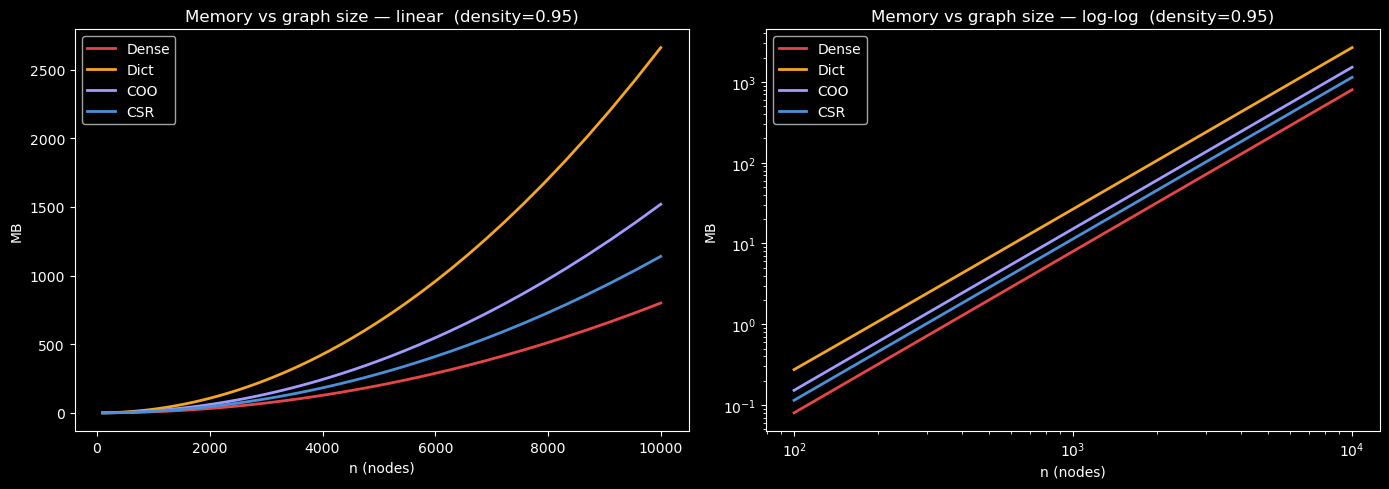

In [5]:
import numpy as np
from scipy.sparse import csr_matrix, coo_matrix
import matplotlib.pyplot as plt
import sys

plt.style.use("dark_background")

density = 0.95

# --- scaling table ---
print(f"{'n':>8} {'density':>10} {'dense MB':>10} {'dict MB':>10} {'COO MB':>10} {'CSR MB':>10}")
print("-" * 64)
for n_test in [5, 10, 50, 100, 500, 1000, 5000, 10000]:
    nnz       = int(n_test ** 2 * density)
    dense_mb  = (n_test ** 2 * 8) / 1e6
    dict_mb   = (n_test * (28 + 56) + nnz * 28) / 1e6
    coo_mb    = (nnz * (8 + 4 + 4)) / 1e6           # data(8) + row(4) + col(4)
    sparse_mb = (nnz * (8 + 4) + n_test * 4) / 1e6  # data(8) + col(4) + indptr(4/row)
    print(f"{n_test:>8,} {density:>10.4f} {dense_mb:>10.4f} {dict_mb:>10.4f} {coo_mb:>10.4f} {sparse_mb:>10.4f}")

# --- plot ---
ns         = np.logspace(2, 4, 100)
dense_mbs  = (ns ** 2 * 8) / 1e6
dict_mbs   = (ns * (28 + 56) + ns ** 2 * density * 28) / 1e6
coo_mbs    = (ns ** 2 * density * (8 + 4 + 4)) / 1e6
sparse_mbs = (ns ** 2 * density * (8 + 4) + ns * 4) / 1e6

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, log in zip(axes, [False, True]):
    plot = ax.loglog if log else ax.plot
    plot(ns, dense_mbs,  label="Dense",  color="#e84545", linewidth=2)
    plot(ns, dict_mbs,   label="Dict",   color="#f5a623", linewidth=2)
    plot(ns, coo_mbs,    label="COO",    color="#a29bfe", linewidth=2)
    plot(ns, sparse_mbs, label="CSR",    color="#4a90d9", linewidth=2)
    ax.set_xlabel("n (nodes)")
    ax.set_ylabel("MB")
    ax.set_title(f"Memory vs graph size {'— log-log' if log else '— linear'}  (density={density})")
    ax.legend()

plt.tight_layout()
plt.show()